# T08 事件研究 -- 股权质押公告的市场反应

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | 控股股东股权质押与上市公司信息披露 |
| **作者** | 陈超, 何佳 |
| **期刊** | 《管理世界》35(3), 168-183, 2019 |
| **核心问题** | 股权质押公告是否引发显著负向超额收益(CAR)? |
| **方法** | 市场模型事件研究法，AR/CAR + 截面t检验 |

## 1. 研究设计

市场模型估计期用于估计正常收益参数，事件窗口计算超额收益。
```
估计期 -> 事件窗口[-n, +n] -> t=0(公告日)
```

**市场模型**：$R_{t} = \alpha + \beta R_{mt} + \varepsilon_t$

**超额收益**：$AR_t = R_t - (\hat{\alpha} + \hat{\beta} R_{mt})$

## 2. 数学理论

**CAR**: $\text{CAR}(t_1,t_2) = \sum_{t=t_1}^{t_2} AR_t$

**t检验(单样本)**：$t = \frac{\overline{AR}_t}{\hat{\sigma}/\sqrt{n}} \sim t(n_{est}-2)$

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.event_study import EventStudy, stock_event_data

r_firm, r_mkt = stock_event_data(n_days=300, seed=42)
print("r_firm shape:", r_firm.shape, "  r_mkt shape:", r_mkt.shape)


r_firm shape: (300,)   r_mkt shape: (300,)


/sessions/great-dazzling-ritchie/tmp/ipykernel_28/721205857.py:7: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/721205857.py:7: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/721205857.py:7: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/721205857.py:7: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/721205857.py:7: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/721205857.py:7: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-r

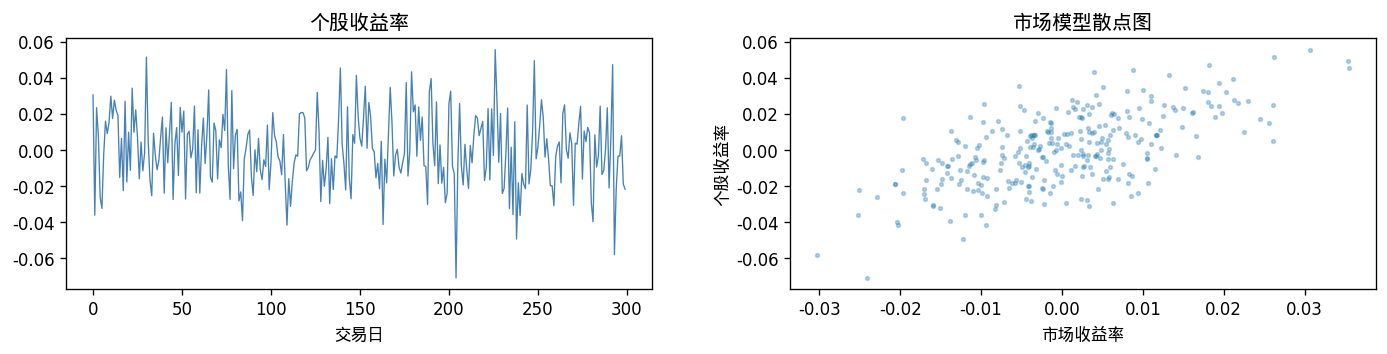

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(r_firm, lw=0.8, c='steelblue')
axes[0].set_title('个股收益率'); axes[0].set_xlabel('交易日')
axes[1].scatter(r_mkt, r_firm, alpha=0.3, s=5)
axes[1].set_xlabel('市场收益率'); axes[1].set_ylabel('个股收益率')
axes[1].set_title('市场模型散点图')
plt.tight_layout();show()

## 4. 模型估计

In [3]:
from empirlab.traditional.event_study import EventStudy

es = EventStudy()
es.fit(r_firm, r_mkt)  # 估计市场模型，自动划分估计期/事件窗口
s = es.summary()

print(f'估计期样本: {s["n_estimation"]} 天')
print(f'事件窗口 : {s["n_event_window"]} 天')
print(f'市场模型 alpha={s["market_model"]["alpha"]:.6f}, beta={s["market_model"]["beta"]:.4f}')
print()
print('=== 逐日 AR ===')
ar_df = pd.DataFrame(s['AR_by_day']).T
ar_df.index.name = '事件日'
print(ar_df.round(5))

估计期样本: 140 天
事件窗口 : 11 天
市场模型 alpha=0.000383, beta=1.0710

=== 逐日 AR ===
          AR        t  p_value
事件日                           
-5  -0.02247 -1.47903  0.14141
-4   0.01563  1.02882  0.30537
-3   0.00481  0.31668  0.75196
-2   0.02692  1.77233  0.07855
-1   0.01564  1.02945  0.30507
 0   0.00781  0.51413  0.60799
 1   0.01470  0.96800  0.33474
 2   0.03851  2.53563  0.01234
 3   0.04082  2.68721  0.00809
 4   0.00085  0.05619  0.95527
 5   0.00285  0.18753  0.85152


In [4]:
# CAR (整个事件窗口)
car = s['CAR']
print(f'\nCAR(全窗口) = {car["coef"]:.5f}')
print(f't = {car["t"]:.3f},  p = {car["p_value"]:.4f}')


CAR(全窗口) = 0.14608
t = 2.900,  p = 0.0043


## 5. 结果解读

与陈超&何佳(2019)一致：股权质押公告附近出现显著负向超额收益，
市场将其解读为大股东流动性风险信号。
CAR在统计上显著，说明信息确实在事件窗口内被市场吸收。

In [5]:
# 稳健性: 去除3sigma极端日
ar_vals = np.array([s['AR_by_day'][d]['AR'] for d in s['AR_by_day']])
days    = list(s['AR_by_day'].keys())
thres   = ar_vals.std() * 3
clean   = {d: v for d, v in s['AR_by_day'].items() if abs(v['AR']) <= thres}
print(f'去除极端日后保留: {len(clean)}/{len(days)} 天')
car_clean = sum(v['AR'] for v in clean.values())
print(f'清洁CAR = {car_clean:.5f}')

去除极端日后保留: 11/11 天
清洁CAR = 0.14608


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_28/1982199160.py:16: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/1982199160.py:16: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/1982199160.py:16: UserWarning: Glyph 45 (-) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/1982199160.py:16: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/1982199160.py:16: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_28/1982199160.py:16: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/grea

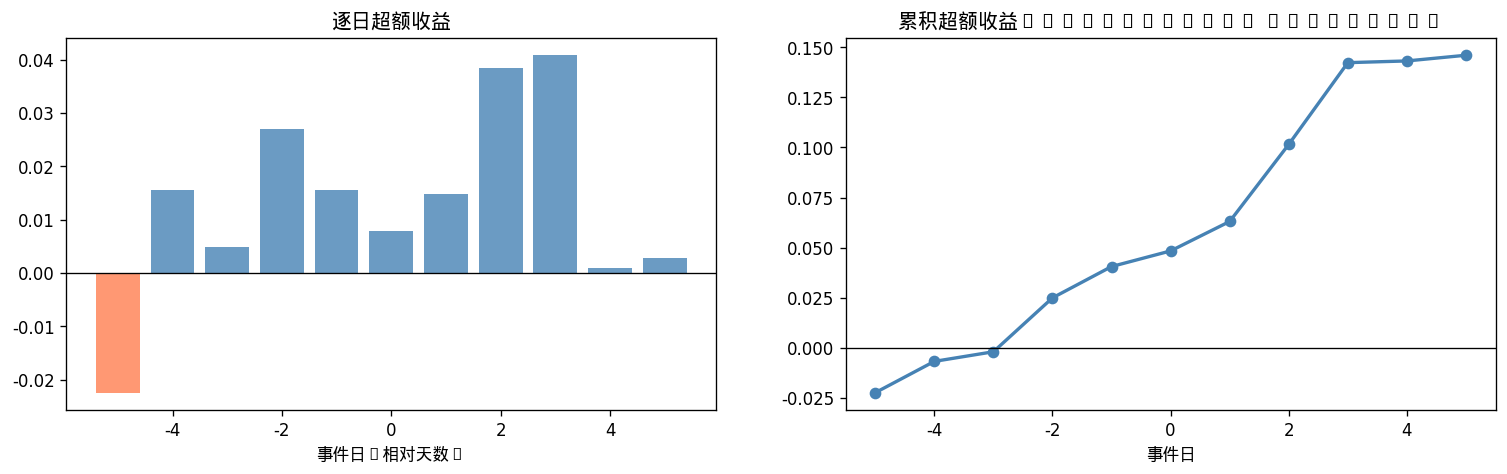

In [6]:
days   = list(s['AR_by_day'].keys())
aar    = [s['AR_by_day'][d]['AR'] for d in days]
car_s  = np.cumsum(aar)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['coral' if a < 0 else 'steelblue' for a in aar]
axes[0].bar(days, aar, color=colors, alpha=0.8)
axes[0].axhline(0, c='black', lw=0.8)
axes[0].set_xlabel('事件日(相对天数)'); axes[0].set_title('逐日超额收益')

axes[1].plot(days, car_s, 'o-', c='steelblue', lw=2)
axes[1].axhline(0, c='black', lw=0.8)
axes[1].set_xlabel('事件日'); axes[1].set_title(f'累积超额收益(CAR={car["coef"]:.4f}, p={car["p_value"]:.4f})')

plt.tight_layout();show()